# Support Vector Machine (SVM)

**Name:** Abdulaziz Aloufi  
**Student ID:** C00266252  
**Module:** Data Science & Machine Learning 2  

## Overview
This notebook implements a Support Vector Machine (SVM) classifier using a dataset about AI and student performance.

The aim is to predict the student's **performance category** (`Low`, `Medium`, `High`) based on AI usage and academic-related features.

In this notebook I will:
- load and inspect the dataset
- prepare the data
- encode categorical columns
- scale the features
- train an SVM classifier
- evaluate the results
- compare different kernel settings

In [1]:
# =====================================================
# Support Vector Machine (SVM)
# Name: Abdulaziz Aloufi
# Student ID: C00266252
# =====================================================

# importing the libraries I need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# setting a nicer style for plots
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

## 1. Load the dataset

For this notebook I am using the same dataset about AI and student performance.

I chose to use the same dataset here because:
- it allows me to compare different algorithms on the same problem
- it has a clear target column called `performance_category`

In [2]:
# loading the dataset
df = pd.read_csv("../data/ai_impact_student_performance_dataset.csv")

# first look at the data
df.head()

,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,...,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,...,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low


In [3]:
# filling missing values in categorical columns
df["ai_tools_used"] = df["ai_tools_used"].fillna("Unknown")
df["ai_usage_purpose"] = df["ai_usage_purpose"].fillna("Unknown")

# checking again
print(df.isnull().sum())
print("\nTotal missing values after fixing:", df.isnull().sum().sum())

student_id                         0
age                                0
gender                             0
grade_level                        0
study_hours_per_day                0
uses_ai                            0
ai_usage_time_minutes              0
ai_tools_used                      0
ai_usage_purpose                   0
ai_dependency_score                0
ai_generated_content_percentage    0
ai_prompts_per_week                0
ai_ethics_score                    0
last_exam_score                    0
assignment_scores_avg              0
attendance_percentage              0
concept_understanding_score        0
study_consistency_index            0
improvement_rate                   0
sleep_hours                        0
social_media_hours                 0
tutoring_hours                     0
class_participation_score          0
final_score                        0
passed                             0
performance_category               0
dtype: int64

Total missing values aft

In [4]:
# separating features and target
X = df.drop(columns=["student_id", "final_score", "passed", "performance_category"])
y = df["performance_category"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (8000, 22)
Target shape: (8000,)


performance_category
Medium    4705
Low       2542
High       753
Name: count, dtype: int64


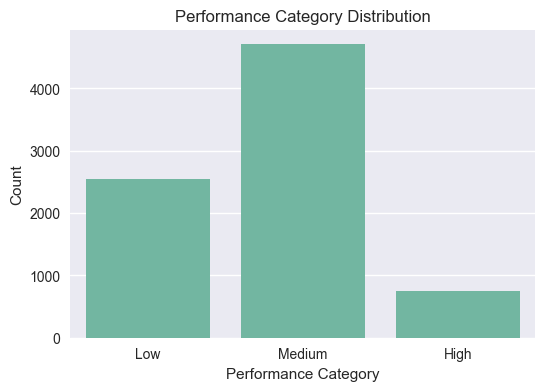

In [5]:
# checking the class distribution
print(y.value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Performance Category Distribution")
plt.xlabel("Performance Category")
plt.ylabel("Count")
plt.show()

In [6]:
# making a copy so I keep the original data safe
X_encoded = X.copy()

# finding categorical columns
cat_cols = X_encoded.select_dtypes(include=["object"]).columns
print("Categorical columns:", list(cat_cols))

Categorical columns: ['gender', 'grade_level', 'ai_tools_used', 'ai_usage_purpose']


In [7]:
# encoding the categorical columns
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    label_encoders[col] = le

# encoding the target labels too
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

# quick check
X_encoded.head()

,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,ai_generated_content_percentage,...,last_exam_score,assignment_scores_avg,attendance_percentage,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score
0,20,0,3,2.5,1,170,5,2,10,29,...,29,40.9,98.8,4,9.0,8.1,7.2,1.5,4.6,6
1,17,1,2,3.4,1,123,5,4,4,14,...,60,87.2,89.3,8,8.5,13.8,7.6,5.1,2.7,6
2,24,1,5,0.8,0,35,3,1,8,82,...,98,77.1,50.8,7,2.1,39.1,5.7,0.2,4.0,3
3,21,0,2,4.4,0,45,1,4,3,74,...,67,86.4,52.1,5,6.7,25.2,8.2,4.2,2.9,2
4,18,2,5,3.5,1,21,1,0,2,83,...,40,69.4,40.7,5,5.4,2.7,8.7,0.2,2.9,2


In [8]:
# splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (6400, 22)
Test shape: (1600, 22)


In [9]:
# scaling the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled training shape: (6400, 22)
Scaled test shape: (1600, 22)


In [10]:
# training the first svm model
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_model.fit(X_train_scaled, y_train)

# predictions
y_pred = svm_model.predict(X_test_scaled)

# accuracy
print("Accuracy (RBF kernel):", accuracy_score(y_test, y_pred))

Accuracy (RBF kernel): 0.84125


In [11]:
# classification report for the first model
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

              precision    recall  f1-score   support

        High       0.81      0.60      0.69       151
         Low       0.84      0.82      0.83       508
      Medium       0.85      0.89      0.87       941

    accuracy                           0.84      1600
   macro avg       0.83      0.77      0.80      1600
weighted avg       0.84      0.84      0.84      1600



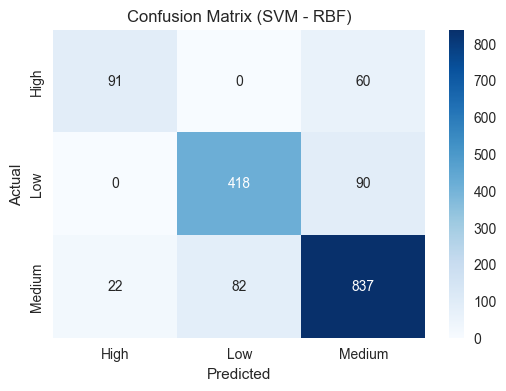

In [12]:
# confusion matrix for the first model
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)
plt.title("Confusion Matrix (SVM - RBF)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
# comparing different kernels
kernels = ["linear", "rbf", "poly", "sigmoid"]
kernel_results = []

for kernel in kernels:
    model = SVC(kernel=kernel, C=1.0, gamma="scale", random_state=42)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    kernel_results.append([kernel, acc])

kernel_results_df = pd.DataFrame(kernel_results, columns=["kernel", "accuracy"])
kernel_results_df

,kernel,accuracy
0,linear,0.845000
1,rbf,0.841250
2,poly,0.809375
3,sigmoid,0.836250


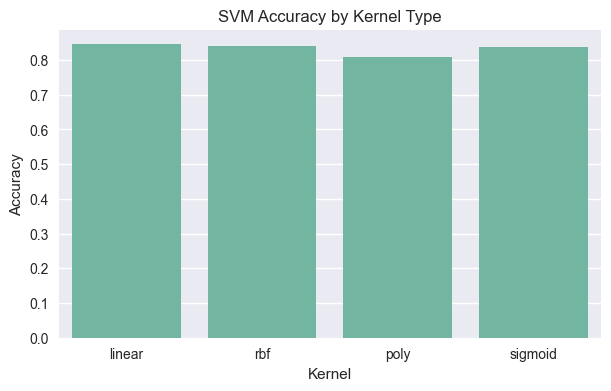

In [14]:
# plotting the kernel comparison
plt.figure(figsize=(7, 4))
sns.barplot(data=kernel_results_df, x="kernel", y="accuracy")
plt.title("SVM Accuracy by Kernel Type")
plt.xlabel("Kernel")
plt.ylabel("Accuracy")
plt.show()

In [15]:
# selecting the best kernel
best_kernel = kernel_results_df.loc[kernel_results_df["accuracy"].idxmax(), "kernel"]
print("Best kernel:", best_kernel)

# training the final model
final_svm = SVC(kernel=best_kernel, C=1.0, gamma="scale", random_state=42)
final_svm.fit(X_train_scaled, y_train)

final_preds = final_svm.predict(X_test_scaled)

print("Final Accuracy:", accuracy_score(y_test, final_preds))

Best kernel: linear
Final Accuracy: 0.845


In [16]:
print(classification_report(y_test, final_preds, target_names=target_encoder.classes_))

              precision    recall  f1-score   support

        High       0.74      0.63      0.68       151
         Low       0.84      0.84      0.84       508
      Medium       0.86      0.88      0.87       941

    accuracy                           0.84      1600
   macro avg       0.82      0.78      0.80      1600
weighted avg       0.84      0.84      0.84      1600



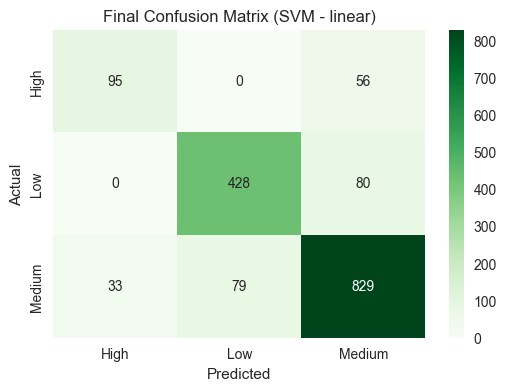

In [17]:
final_cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(6, 4))
sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)
plt.title(f"Final Confusion Matrix (SVM - {best_kernel})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 9. Conclusion

In this notebook I implemented Support Vector Machine (SVM) classification using a dataset about AI and student performance.

### Summary of work completed
- loaded and explored the dataset
- checked and fixed missing values in categorical columns
- selected `performance_category` as the target variable
- removed `student_id`, `final_score`, and `passed` from the features
- encoded categorical columns using `LabelEncoder`
- split the data into training and test sets
- scaled the features using `StandardScaler`
- trained an initial SVM model using the RBF kernel
- evaluated the model using accuracy, classification report, and confusion matrix
- compared four kernel types:
  - linear
  - rbf
  - poly
  - sigmoid
- selected the best-performing kernel and trained the final model

### Results
The first SVM model using the **RBF kernel** achieved an accuracy of **0.8413**.

After comparing multiple kernels, the **linear kernel** gave the best result, with a final accuracy of **0.8450**.

The final model performed best on the `Medium` and `Low` classes, while the `High` class was more difficult to classify. This is likely related to the class imbalance in the dataset, since `High` has far fewer examples than the other categories.

### Reflection
This notebook showed that SVM is a strong classification method for this dataset. It also showed that feature scaling is important and that kernel choice affects performance.
